# ⚡ Consumo de Energia Elétrica no Brasil (2015–2024)
**Projeto G1 — Linguagem de Programação: Análise e Visualização de Dados com Python**
Tema 14 · Aluno: Hiago da Silva Arruda

## 1. Introdução
O objetivo é investigar padrões de consumo de energia elétrica no Brasil entre 2015 e 2024: quais estados e setores consomem mais, como o consumo evolui, se há sazonalidade, se a temperatura se relaciona com o consumo e onde estão os riscos de demanda.

## 2. Contextualização energética
O consumo de energia é um indicador econômico e social: reflete crescimento urbano, atividade industrial e eficiência energética. Monitorá-lo permite identificar sazonalidade, picos de demanda e risco de sobrecarga do sistema elétrico. A base usada é **simulada** (fornecida pelo professor), então os resultados valem para aprender a técnica, não para concluir sobre o sistema elétrico real.

**Perguntas orientadoras:** quais estados e setores consomem mais? há sazonalidade? o consumo aumentou? há relação entre temperatura e consumo? há picos de demanda? qual região cresce mais?

## 3. Explicação da base de dados
Arquivo `simulacao_consumo_energia_brasil.csv` — 4.440 linhas × 14 colunas.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período da medição |
| regiao, uf | Região e estado |
| setor_consumo | Residencial, Industrial, Comercial, Rural, Público |
| consumo_mwh | Consumo em MWh |
| demanda_pico | Demanda máxima registrada |
| temperatura_media | Temperatura média (°C) |
| tarifa_media | Tarifa média |
| populacao | População estimada |
| eficiencia_energetica | Índice de eficiência |
| emissao_co2 | Emissão estimada de CO₂ |
| nivel_demanda | Baixo, Médio, Alto, Crítico |

## 4. Leitura dos dados

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../imagens"); IMG.mkdir(exist_ok=True)

df = pd.read_csv("../dados/simulacao_consumo_energia_brasil.csv")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,setor_consumo,consumo_mwh,demanda_pico,temperatura_media,tarifa_media,populacao,eficiencia_energetica,emissao_co2,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Residencial,7684.77,3178.13,24.3,0.55,2250552,46.62,53279.77,Crítico
1,2015,1,2015-01-01,Norte,PA,Industrial,71916.97,1068.50,26.4,0.77,1798475,68.00,35032.42,Médio
2,2015,1,2015-01-01,Norte,PA,Industrial,43309.99,17894.03,28.3,0.82,2796992,62.74,28792.52,Alto
3,2015,1,2015-01-01,Norte,RO,Público,13481.31,5769.72,29.5,1.04,4489483,84.33,48501.26,Médio
4,2015,1,2015-01-01,Norte,TO,Público,28250.05,2522.50,21.8,0.66,5179949,91.22,14460.94,Baixo


In [2]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    4440 non-null   int64  
 1   mes                    4440 non-null   int64  
 2   data                   4440 non-null   str    
 3   regiao                 4440 non-null   str    
 4   uf                     4440 non-null   str    
 5   setor_consumo          4440 non-null   str    
 6   consumo_mwh            4440 non-null   float64
 7   demanda_pico           4440 non-null   float64
 8   temperatura_media      4440 non-null   float64
 9   tarifa_media           4440 non-null   float64
 10  populacao              4440 non-null   int64  
 11  eficiencia_energetica  4440 non-null   float64
 12  emissao_co2            4440 non-null   float64
 13  nivel_demanda          4440 non-null   str    
dtypes: float64(6), int64(3), str(5)
memory usage: 630.2 KB


,count,mean,std,min,25%,50%,75%,max
ano,4440.0,2.019500e+03,2.872605e+00,2015.00,2.017000e+03,2019.50,2.022000e+03,2024.00
mes,4440.0,6.500000e+00,3.452441e+00,1.00,3.750000e+00,6.50,9.250000e+00,12.00
consumo_mwh,4440.0,3.731939e+04,5.045257e+04,826.34,1.132851e+04,22530.66,4.460437e+04,1018566.37
demanda_pico,4440.0,4.820636e+03,5.850414e+03,137.23,1.450900e+03,2973.45,5.877255e+03,99194.11
temperatura_media,4440.0,2.496872e+01,3.925635e+00,9.00,2.230000e+01,25.00,2.760000e+01,39.00
tarifa_media,4440.0,8.491036e-01,1.749427e-01,0.55,7.000000e-01,0.85,1.000000e+00,1.15
populacao,4440.0,3.065113e+06,1.706768e+06,100186.00,1.594904e+06,3095562.50,4.562464e+06,5999809.00
eficiencia_energetica,4440.0,6.979645e+01,1.450390e+01,45.01,5.724000e+01,69.93,8.223000e+01,95.00
emissao_co2,4440.0,4.050982e+04,2.303498e+04,100.80,2.077538e+04,40520.82,6.057805e+04,79995.97


## 5. Limpeza e preparação

In [3]:
print("Valores nulos por coluna:"); print(df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else "nenhum")
print("Linhas duplicadas:", df.duplicated().sum())

df["data"] = pd.to_datetime(df["data"])
ordem = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_demanda"] = pd.Categorical(df["nivel_demanda"], categories=ordem, ordered=True)

# consistência: valores impossíveis?
print("consumo <= 0:", (df.consumo_mwh <= 0).sum(), "| tarifa <= 0:", (df.tarifa_media <= 0).sum(),
      "| eficiência fora de 0-100:", (~df.eficiencia_energetica.between(0, 100)).sum())

# outliers de consumo (regra do IQR) — mantidos, pois são valores plausíveis (grandes consumidores)
q1, q3 = df.consumo_mwh.quantile([.25, .75]); lim = q3 + 1.5 * (q3 - q1)
print(f"Outliers de consumo (> {lim:,.0f} MWh): {(df.consumo_mwh > lim).sum()} registros")

# cobertura da base
print("\nRegistros por ano:", df.groupby("ano").size().unique())
print("Registros por UF:"); print(df.groupby("uf").size().sort_values(ascending=False).to_dict())

Valores nulos por coluna:
nenhum
Linhas duplicadas: 0
consumo <= 0: 0 | tarifa <= 0: 0 | eficiência fora de 0-100: 0
Outliers de consumo (> 94,518 MWh): 327 registros

Registros por ano: [444]
Registros por UF:
{'RJ': 480, 'MG': 360, 'ES': 360, 'SP': 360, 'SC': 240, 'RS': 240, 'CE': 240, 'BA': 240, 'PE': 240, 'PR': 240, 'GO': 240, 'PA': 240, 'DF': 120, 'AM': 120, 'MS': 120, 'MA': 120, 'PB': 120, 'MT': 120, 'RO': 120, 'TO': 120}


**Resultado da limpeza:** a base não tem nulos, duplicatas nem valores impossíveis. Os tipos foram corrigidos (`data` → datetime, `nivel_demanda` → categoria ordenada).

⚠️ **Atenção importante:** a base tem **20 estados** (não os 27) e o número de registros por estado é **desigual** (ex.: RJ tem 480 linhas; AM, DF, MA e outros têm 120). Isso faz o *total* de consumo favorecer estados com mais registros — por isso, além do total, usamos também a **média por registro**. Os outliers foram mantidos por serem plausíveis.

## 6. Engenharia de atributos

In [4]:
df["mes_nome"] = df["mes"].map({1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"})
df["consumo_per_capita"] = df["consumo_mwh"] / df["populacao"]
df["custo_estimado"] = df["consumo_mwh"] * df["tarifa_media"]
df["emissao_por_mwh"] = df["emissao_co2"] / df["consumo_mwh"]
mensal = df.groupby("data", as_index=False)["consumo_mwh"].sum().sort_values("data")
mensal["media_movel_12m"] = mensal["consumo_mwh"].rolling(12).mean()
df[["consumo_per_capita", "custo_estimado", "emissao_por_mwh"]].describe().T

,count,mean,std,min,25%,50%,75%,max
consumo_per_capita,4440.0,0.027039,0.082795,0.000223,0.003786,0.008819,0.021502,2.769085
custo_estimado,4440.0,31558.583091,43297.157779,858.984300,9347.118475,18582.328250,37863.069450,750009.690000
emissao_por_mwh,4440.0,3.014504,4.787958,0.001004,0.625326,1.523388,3.537870,64.546769


## 7. KPIs

In [5]:
por_uf = df.groupby("uf")["consumo_mwh"].sum().sort_values(ascending=False)
por_setor = df.groupby("setor_consumo")["consumo_mwh"].sum().sort_values(ascending=False)
kpis = {
    "Consumo total (MWh)": f"{df.consumo_mwh.sum():,.0f}",
    "Estado com maior consumo": f"{por_uf.index[0]} ({por_uf.iloc[0]:,.0f} MWh)",
    "Setor mais consumidor": f"{por_setor.index[0]} ({por_setor.iloc[0]:,.0f} MWh)",
    "Demanda de pico média (MW)": f"{df.demanda_pico.mean():,.1f}",
    "Tarifa média": f"{df.tarifa_media.mean():.2f}",
    "Emissão total de CO₂": f"{df.emissao_co2.sum():,.0f}",
    "% de registros em nível Crítico": f"{(df.nivel_demanda=='Crítico').mean()*100:.1f}%",
}
pd.Series(kpis, name="Valor").to_frame()

,Valor
Consumo total (MWh),"165,698,083"
Estado com maior consumo,"RJ (17,580,198 MWh)"
Setor mais consumidor,"Público (34,193,191 MWh)"
Demanda de pico média (MW),"4,820.6"
Tarifa média,0.85
Emissão total de CO₂,"179,863,584"
% de registros em nível Crítico,24.7%


## 8. Visualizações

### 8.1 Evolução temporal do consumo

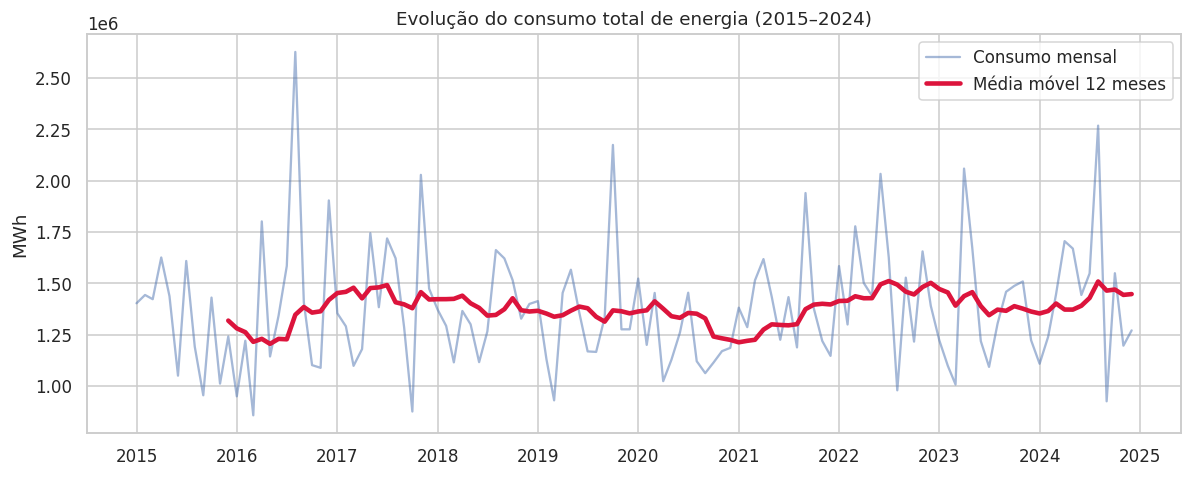

ano
2016     7.6
2017     0.2
2018    -4.1
2019    -0.7
2020    -9.5
2021    14.1
2022     7.5
2023    -9.3
2024     6.2


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(mensal["data"], mensal["consumo_mwh"], alpha=.5, label="Consumo mensal")
ax.plot(mensal["data"], mensal["media_movel_12m"], color="crimson", lw=3, label="Média móvel 12 meses")
ax.set(title="Evolução do consumo total de energia (2015–2024)", ylabel="MWh", xlabel="")
ax.legend(); plt.tight_layout(); plt.savefig(IMG / "01_evolucao_temporal.png"); plt.show()

anual = df.groupby("ano")["consumo_mwh"].sum()
print((anual.pct_change() * 100).round(1).dropna().to_string())

### 8.2 Ranking de estados (total e média por registro)

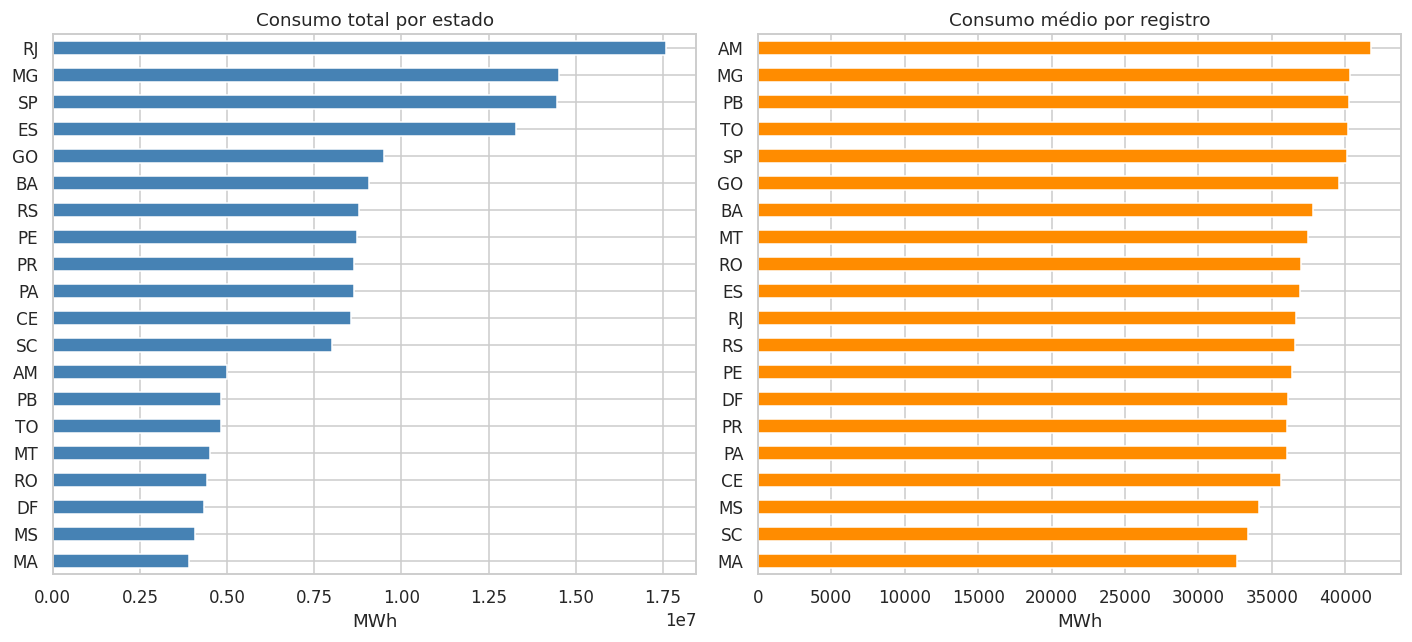

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
por_uf.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set(title="Consumo total por estado", xlabel="MWh", ylabel="")
media_uf = df.groupby("uf")["consumo_mwh"].mean().sort_values()
media_uf.plot.barh(ax=axes[1], color="darkorange")
axes[1].set(title="Consumo médio por registro", xlabel="MWh", ylabel="")
plt.tight_layout(); plt.savefig(IMG / "02_ranking_estados.png"); plt.show()

### 8.3 Comparação regional

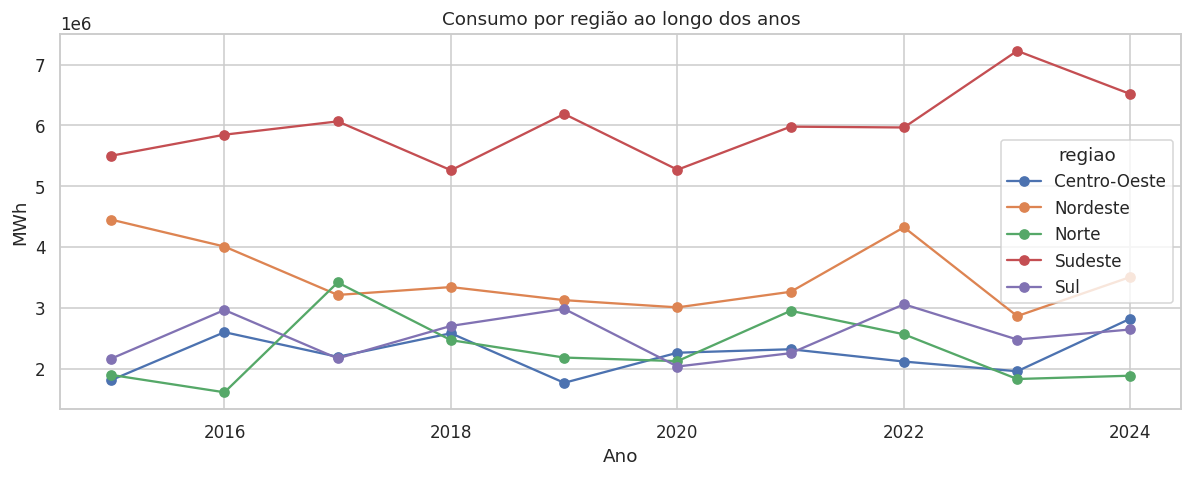

Crescimento 2015 → 2024 por região (%):
regiao
Centro-Oeste    55.9
Sul             22.2
Sudeste         18.4
Norte           -0.7
Nordeste       -21.2


In [8]:
reg_ano = df.pivot_table(index="ano", columns="regiao", values="consumo_mwh", aggfunc="sum")
ax = reg_ano.plot(figsize=(11, 4.5), marker="o")
ax.set(title="Consumo por região ao longo dos anos", ylabel="MWh", xlabel="Ano")
plt.tight_layout(); plt.savefig(IMG / "03_regioes.png"); plt.show()
cresc = ((reg_ano.loc[2024] / reg_ano.loc[2015] - 1) * 100).sort_values(ascending=False).round(1)
print("Crescimento 2015 → 2024 por região (%):"); print(cresc.to_string())

### 8.4 Comparação entre setores

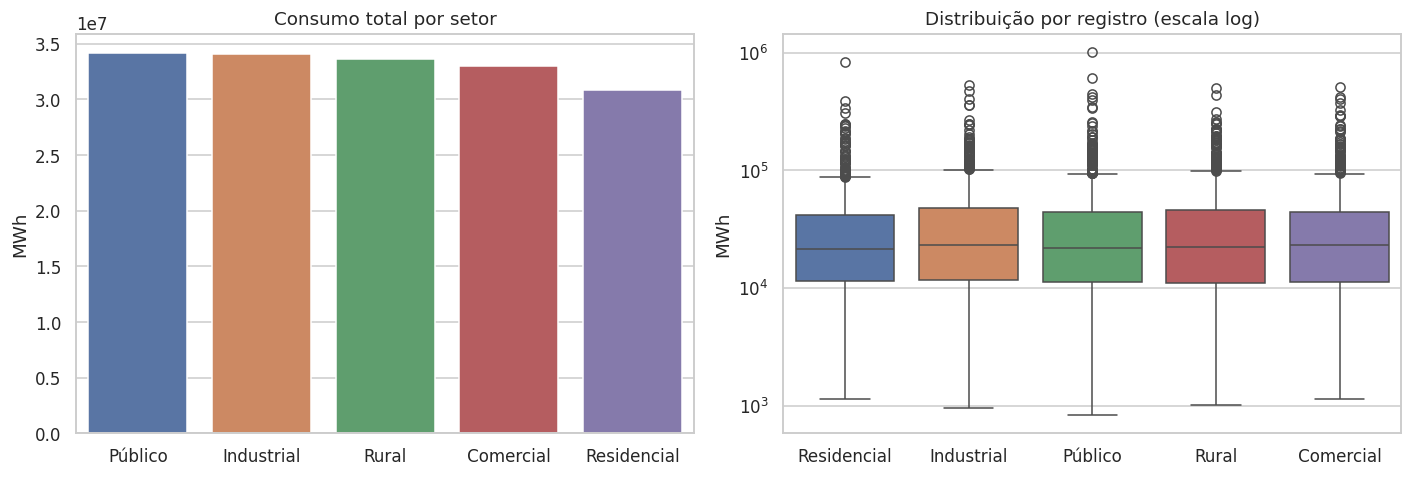

Diferença entre o maior e o menor setor: 10.9%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=por_setor.index, y=por_setor.values, ax=axes[0], hue=por_setor.index, legend=False)
axes[0].set(title="Consumo total por setor", ylabel="MWh", xlabel="")
sns.boxplot(data=df, x="setor_consumo", y="consumo_mwh", ax=axes[1], hue="setor_consumo", legend=False)
axes[1].set(yscale="log", title="Distribuição por registro (escala log)", ylabel="MWh", xlabel="")
plt.tight_layout(); plt.savefig(IMG / "04_setores.png"); plt.show()
print(f"Diferença entre o maior e o menor setor: {(por_setor.iloc[0]/por_setor.iloc[-1]-1)*100:.1f}%")

### 8.5 Sazonalidade (heatmap mensal)

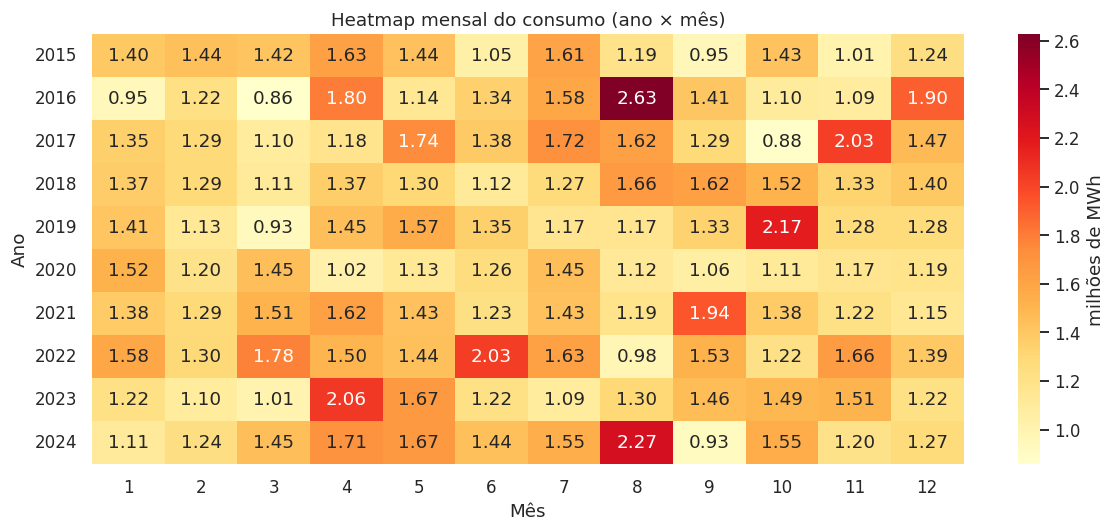

Mês de maior consumo em cada ano: {2015: 4, 2016: 8, 2017: 11, 2018: 8, 2019: 10, 2020: 1, 2021: 9, 2022: 6, 2023: 4, 2024: 8}


In [10]:
heat = df.pivot_table(index="ano", columns="mes", values="consumo_mwh", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat / 1e6, cmap="YlOrRd", annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "milhões de MWh"})
ax.set(title="Heatmap mensal do consumo (ano × mês)", xlabel="Mês", ylabel="Ano")
plt.tight_layout(); plt.savefig(IMG / "05_heatmap_sazonalidade.png"); plt.show()
print("Mês de maior consumo em cada ano:", heat.idxmax(axis=1).to_dict())

### 8.6 Temperatura × consumo e correlação estatística

Pearson = -0.002 | Spearman = 0.006


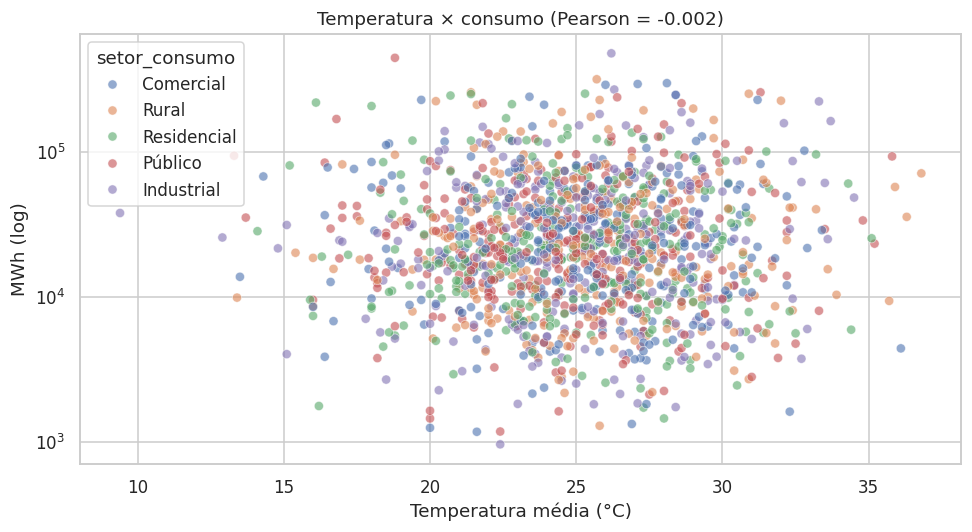

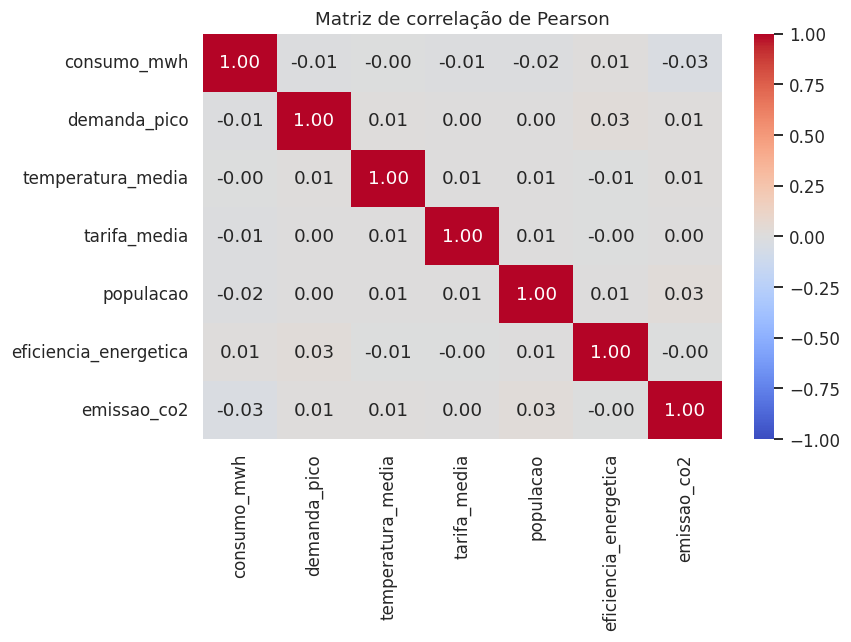

In [11]:
r_p = df.temperatura_media.corr(df.consumo_mwh)
r_s = df.temperatura_media.corr(df.consumo_mwh, method="spearman")
print(f"Pearson = {r_p:.3f} | Spearman = {r_s:.3f}")
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df.sample(1500, random_state=1), x="temperatura_media", y="consumo_mwh", hue="setor_consumo", alpha=.6, ax=ax)
ax.set(yscale="log", title=f"Temperatura × consumo (Pearson = {r_p:.3f})", xlabel="Temperatura média (°C)", ylabel="MWh (log)")
plt.tight_layout(); plt.savefig(IMG / "06_temperatura_consumo.png"); plt.show()

cols = ["consumo_mwh","demanda_pico","temperatura_media","tarifa_media","populacao","eficiencia_energetica","emissao_co2"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação de Pearson")
plt.tight_layout(); plt.savefig(IMG / "07_correlacao.png"); plt.show()

### 8.7 Demanda de pico e eficiência energética

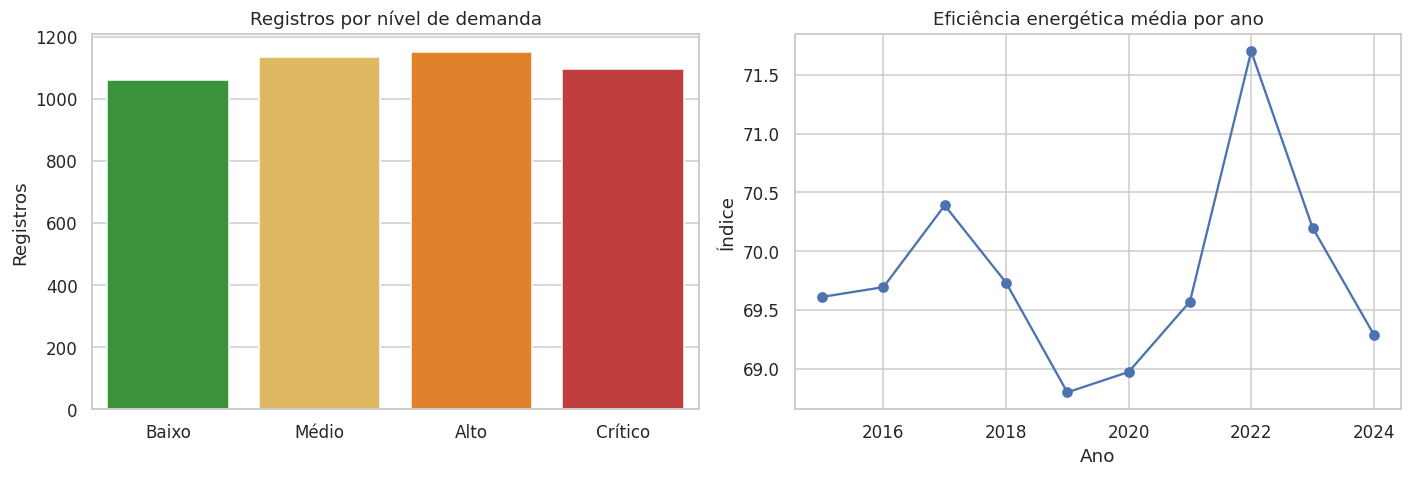

      data uf setor_consumo  demanda_pico nivel_demanda
2022-04-01 SP       Público      99194.11       Crítico
2015-08-01 MA   Residencial      93357.13         Médio
2018-11-01 SP         Rural      68788.18          Alto
2024-01-01 RJ       Público      59025.14       Crítico
2022-06-01 MG     Comercial      57765.56         Médio


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cont = df["nivel_demanda"].value_counts().reindex(ordem)
sns.barplot(x=cont.index, y=cont.values, ax=axes[0], hue=cont.index, legend=False,
            palette=["#2ca02c", "#f2c14e", "#ff7f0e", "#d62728"])
axes[0].set(title="Registros por nível de demanda", xlabel="", ylabel="Registros")
efic = df.groupby("ano")["eficiencia_energetica"].mean()
axes[1].plot(efic.index, efic.values, marker="o")
axes[1].set(title="Eficiência energética média por ano", xlabel="Ano", ylabel="Índice")
plt.tight_layout(); plt.savefig(IMG / "08_demanda_eficiencia.png"); plt.show()
print(df.nlargest(5, "demanda_pico")[["data","uf","setor_consumo","demanda_pico","nivel_demanda"]].to_string(index=False))

## 9. Interpretação dos resultados
- **Estados:** no total, RJ (≈17,6 mi MWh), MG e SP lideram — mas o total é influenciado pelo número de registros de cada estado (RJ tem 4× mais linhas que AM, por exemplo). Na média por registro o ranking muda, o que mostra a importância de olhar a métrica certa.
- **Setores:** Público, Industrial e Rural ficam muito próximos; a diferença entre o maior e o menor setor (Residencial) é de cerca de 11%. Consumo bem distribuído.
- **Evolução:** o consumo anual não cresce de forma contínua: cai em 2020 (menor valor da série) e se recupera em 2021–2022, com nova queda em 2023.
- **Regiões:** de 2015 a 2024 o Centro-Oeste teve o maior crescimento (≈ +56%) e o Nordeste a maior queda (≈ −21%). Como o número de registros por região/ano varia, esses percentuais devem ser lidos com cautela.
- **Sazonalidade:** o mês de pico muda de ano para ano; não há um padrão sazonal estável no heatmap.
- **Temperatura:** correlação praticamente nula (Pearson ≈ 0). Em dados reais esperaríamos aumento de consumo em períodos quentes; aqui as variáveis foram geradas de forma independente.
- **Demanda:** cerca de 25% dos registros estão em nível *Crítico*, distribuídos de forma parecida entre os níveis; a eficiência média fica estável (≈ 69–72).

## 10. Conclusão
O projeto cumpriu o ciclo completo: leitura, limpeza, engenharia de atributos, KPIs, visualizações e interpretação. Os principais achados foram: (1) o consumo oscila ao longo dos anos, com queda em 2020; (2) o consumo é equilibrado entre setores; (3) não há sazonalidade nem relação entre temperatura e consumo; (4) o ranking de estados por total deve ser lido junto com a média por registro, pois a base é desbalanceada.

**Limitações:** base simulada e com 20 estados, sem relações realistas entre as variáveis. **Próximos passos:** testar com dados reais (ex.: EPE/ONS), incluir persistência em SQLite e modelos de previsão de consumo.